In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# Data Loading and Combination
def load_radar_data(data_dir):
    """Load and combine all radar JSON files from 2-people and 3-people experiments"""
    
    data_dir = Path(data_dir)
    all_features = []
    all_labels = []
    
    json_files = list(data_dir.rglob("*.json"))
    print(f"Found {len(json_files)} JSON files")
    
    for json_file in json_files:
        print(f"Processing: {json_file.name}")
        
        # Extract group size from path
        if "2 People" in str(json_file.parent.parent):
            label = 0  # 2-people group
        elif "3 People" in str(json_file.parent.parent):
            label = 1  # 3-people group
        else:
            continue
            
        # Load JSON data
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        # Extract features from each frame
        for frame in data['data']:
            try:
                frame_data = frame['frameData']
                num_points = frame_data.get('numDetectedPoints', len(frame_data.get('pointCloud', [])))
                point_cloud = frame_data.get('pointCloud', [])
                
                if num_points >= 2 and point_cloud:  # Only high-quality frames
                    points = np.array(point_cloud)
                    
                    # Basic frame features
                    features = [num_points]  # Will add more features in next step
                    
                    all_features.append(features)
                    all_labels.append(label)
                    
            except Exception:
                continue
    
    return np.array(all_features), np.array(all_labels)

# Load the data
data_path = "../Data/Social Exp Data"
X_basic, y = load_radar_data(data_path)

print(f"\nData loaded successfully!")
print(f"Total samples: {len(X_basic):,}")
print(f"2-people samples: {sum(y == 0):,}")
print(f"3-people samples: {sum(y == 1):,}")


Found 10 JSON files
Processing: replay_32.json
Processing: replay_47.json
Processing: replay_30.json
Processing: replay_28.json
Processing: replay_23.json
Processing: replay_21.json
Processing: replay_22.json
Processing: replay_23.json
Processing: replay_25.json
Processing: replay_17.json

Data loaded successfully!
Total samples: 23,973
2-people samples: 8,941
3-people samples: 15,032


In [6]:
# Feature Engineering - Extract detailed features from point clouds
def extract_features(data_dir):
    """Extract comprehensive features from radar data"""
    
    data_dir = Path(data_dir)
    all_features = []
    all_labels = []
    
    json_files = list(data_dir.rglob("*.json"))
    
    for json_file in json_files:
        # Extract group size from path
        if "2 People" in str(json_file.parent.parent):
            label = 0  # 2-people group
        elif "3 People" in str(json_file.parent.parent):
            label = 1  # 3-people group
        else:
            continue
            
        # Load JSON data
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        # Extract features from each frame (data already filtered to >=2 points)
        for frame in data['data']:
            try:
                frame_data = frame['frameData']
                num_points = frame_data.get('numDetectedPoints', len(frame_data.get('pointCloud', [])))
                point_cloud = frame_data.get('pointCloud', [])
                
                if point_cloud:  # Only check if point cloud exists
                    points = np.array(point_cloud)
                    
                    # Spatial coordinates
                    x_coords = points[:, 0]
                    y_coords = points[:, 1] 
                    z_coords = points[:, 2]
                    
                    # Feature vector - 12 features total
                    features = [
                        num_points,                           # 1. Number of detected points
                        np.mean(x_coords),                   # 2. Mean X position
                        np.mean(y_coords),                   # 3. Mean Y position  
                        np.mean(z_coords),                   # 4. Mean Z position
                        np.std(x_coords),                    # 5. X spread
                        np.std(y_coords),                    # 6. Y spread
                        np.std(z_coords),                    # 7. Z spread
                        np.max(x_coords) - np.min(x_coords), # 8. X range
                        np.max(y_coords) - np.min(y_coords), # 9. Y range
                        np.max(z_coords) - np.min(z_coords), # 10. Z range
                        np.sum(points[:, 4]) if points.shape[1] > 4 else 0,  # 11. Total velocity
                        len(np.unique(points, axis=0)) / len(points) # 12. Point density
                    ]
                    
                    all_features.append(features)
                    all_labels.append(label)
                    
            except Exception:
                continue
    
    return np.array(all_features), np.array(all_labels)

# Extract comprehensive features
X, y = extract_features(data_path)

print("Feature Engineering Complete!")
print(f"Total samples: {len(X):,}")
print(f"Features per sample: {X.shape[1]}")
print(f"2-people samples: {sum(y == 0):,}")
print(f"3-people samples: {sum(y == 1):,}")

# Feature names for reference
feature_names = ['Num Points', 'Mean X', 'Mean Y', 'Mean Z', 'Std X', 'Std Y', 
                'Std Z', 'Range X', 'Range Y', 'Range Z', 'Total Vel', 'Density']
print(f"\nFeatures: {feature_names}")

Feature Engineering Complete!
Total samples: 23,973
Features per sample: 12
2-people samples: 8,941
3-people samples: 15,032

Features: ['Num Points', 'Mean X', 'Mean Y', 'Mean Z', 'Std X', 'Std Y', 'Std Z', 'Range X', 'Range Y', 'Range Z', 'Total Vel', 'Density']


In [ ]:
# K-Means Clustering
print("Applying K-Means clustering...")

# Apply K-means with k=2 clusters (2-people vs 3-people)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_predictions = kmeans.fit_predict(X_train_scaled)

# Map cluster labels to match true labels
# Check which cluster corresponds to which group size
cluster_0_true = y_train[cluster_predictions == 0]
cluster_1_true = y_train[cluster_predictions == 1]

# Find majority class for each cluster
cluster_0_majority = np.bincount(cluster_0_true).argmax()
cluster_1_majority = np.bincount(cluster_1_true).argmax()

print(f"Cluster 0 majority: {'2-people' if cluster_0_majority == 0 else '3-people'}")
print(f"Cluster 1 majority: {'2-people' if cluster_1_majority == 0 else '3-people'}")

# Adjust labels if needed so cluster 0 = 2-people, cluster 1 = 3-people
if cluster_0_majority == 1:  # If cluster 0 is actually 3-people
    cluster_predictions = 1 - cluster_predictions  # Flip labels

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, cluster_predictions)

print(f"\nK-Means Training Results:")
print(f"Training accuracy: {train_accuracy:.3f} ({train_accuracy:.1%})")

# Apply to test set
test_predictions = kmeans.predict(X_test_scaled)
if cluster_0_majority == 1:  # Apply same label mapping
    test_predictions = 1 - test_predictions

test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test accuracy: {test_accuracy:.3f} ({test_accuracy:.1%})")

Applying K-Means clustering...
Cluster 0 majority: 3-people
Cluster 1 majority: 3-people

K-Means Training Results:
Training accuracy: 0.518 (51.8%)
Test accuracy: 0.515 (51.5%)


Analyzing Model Performance...

Detailed Results:
Total test samples: 7,192
Correct predictions: 3,701
Wrong predictions: 3,491
Final accuracy: 51.5%

Confusion Matrix:
True\Predicted    2-people  3-people
2-people              991      1691
3-people             1800      2710

Classification Report:
              precision    recall  f1-score   support

    2-people       0.36      0.37      0.36      2682
    3-people       0.62      0.60      0.61      4510

    accuracy                           0.51      7192
   macro avg       0.49      0.49      0.49      7192
weighted avg       0.52      0.51      0.52      7192


Performance Assessment: FAIR (better than random)


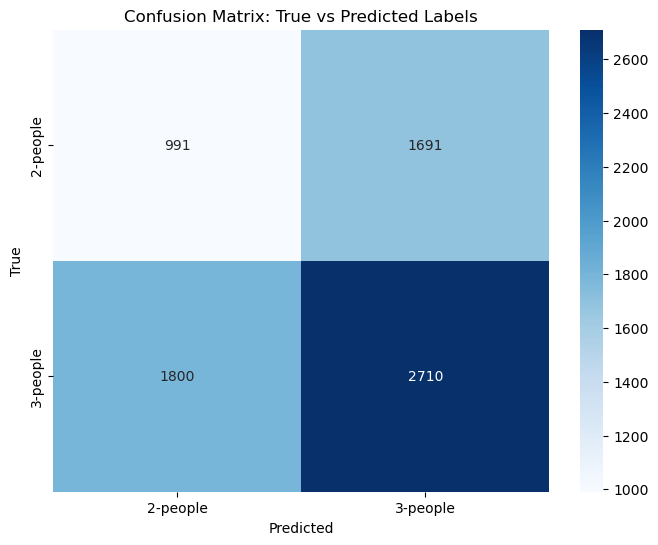

In [ ]:
# Performance Analysis - True Labels vs Model Predictions
print("Analyzing Model Performance...")

# Detailed comparison
correct_predictions = sum(y_test == test_predictions)
wrong_predictions = len(y_test) - correct_predictions

print(f"\nDetailed Results:")
print(f"Total test samples: {len(y_test):,}")
print(f"Correct predictions: {correct_predictions:,}")
print(f"Wrong predictions: {wrong_predictions:,}")
print(f"Final accuracy: {test_accuracy:.1%}")

# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)
print(f"\nConfusion Matrix:")
print("True\\Predicted    2-people  3-people")
print(f"2-people         {cm[0,0]:8d}  {cm[0,1]:8d}")
print(f"3-people         {cm[1,0]:8d}  {cm[1,1]:8d}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, test_predictions, 
                          target_names=['2-people', '3-people']))

# Performance Assessment
if test_accuracy > 0.8:
    performance = "EXCELLENT"
elif test_accuracy > 0.7:
    performance = "GOOD"
elif test_accuracy > 0.5:
    performance = "FAIR (better than random)"
else:
    performance = "POOR (worse than random)"

print(f"\nPerformance Assessment: {performance}")

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: True vs Predicted Labels')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['2-people', '3-people'])
plt.yticks([0.5, 1.5], ['2-people', '3-people'])
plt.show()

In [ ]:
# Summary Results
print("="*60)
print("K-MEANS CLUSTERING ANALYSIS SUMMARY")
print("="*60)

print(f"\n1. DATA OVERVIEW:")
print(f"   Total samples: {len(X):,}")
print(f"   2-people samples: {sum(y == 0):,}")
print(f"   3-people samples: {sum(y == 1):,}")
print(f"   Features used: {X.shape[1]}")

print(f"\n2. TRAIN-TEST SPLIT:")
print(f"   Training: {len(X_train):,} samples")
print(f"   Testing: {len(X_test):,} samples")

print(f"\n3. K-MEANS RESULTS:")
print(f"   Training accuracy: {train_accuracy:.1%}")
print(f"   Testing accuracy: {test_accuracy:.1%}")

print(f"\n4. MODEL PERFORMANCE:")
print(f"   Correct predictions: {correct_predictions:,} / {len(y_test):,}")
print(f"   Classification: {performance}")

print(f"\n5. CONCLUSION:")
if test_accuracy > 0.7:
    conclusion = "K-means successfully distinguishes between group sizes"
elif test_accuracy > 0.5:
    conclusion = "K-means shows some ability to distinguish groups, but needs improvement"
else:
    conclusion = "K-means cannot reliably distinguish between 2-people and 3-people groups"

print(f"   {conclusion}")
print("="*60)

K-MEANS CLUSTERING ANALYSIS SUMMARY

1. DATA OVERVIEW:
   Total samples: 23,973
   2-people samples: 8,941
   3-people samples: 15,032
   Features used: 12

2. TRAIN-TEST SPLIT:
   Training: 16,781 samples
   Testing: 7,192 samples

3. K-MEANS RESULTS:
   Training accuracy: 51.8%
   Testing accuracy: 51.5%

4. MODEL PERFORMANCE:
   Correct predictions: 3,701 / 7,192
   Classification: FAIR (better than random)

5. CONCLUSION:
   K-means shows some ability to distinguish groups, but needs improvement


In [ ]:
# Clear workspace for fresh start
%reset -f